# Explore here

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

url = "https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [6]:
df.info()

print("\n--- Valores '?' por columna ---")
for col in df.select_dtypes(include=['object', 'str']).columns:
    n_missing = (df[col] == '?').sum()
    if n_missing > 0:
        print(f"{col}: {n_missing} ({n_missing/len(df)*100:.2f}%)")

print("\n--- Distribución del target ---")
print(df['income'].value_counts())
print(df['income'].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB

--- Valores '?' por columna ---
workclass: 1836 (5.64%)
occupation: 1843 (5.66%)
native.country: 583 (1.79%)

--- Distribuci

**EDA**

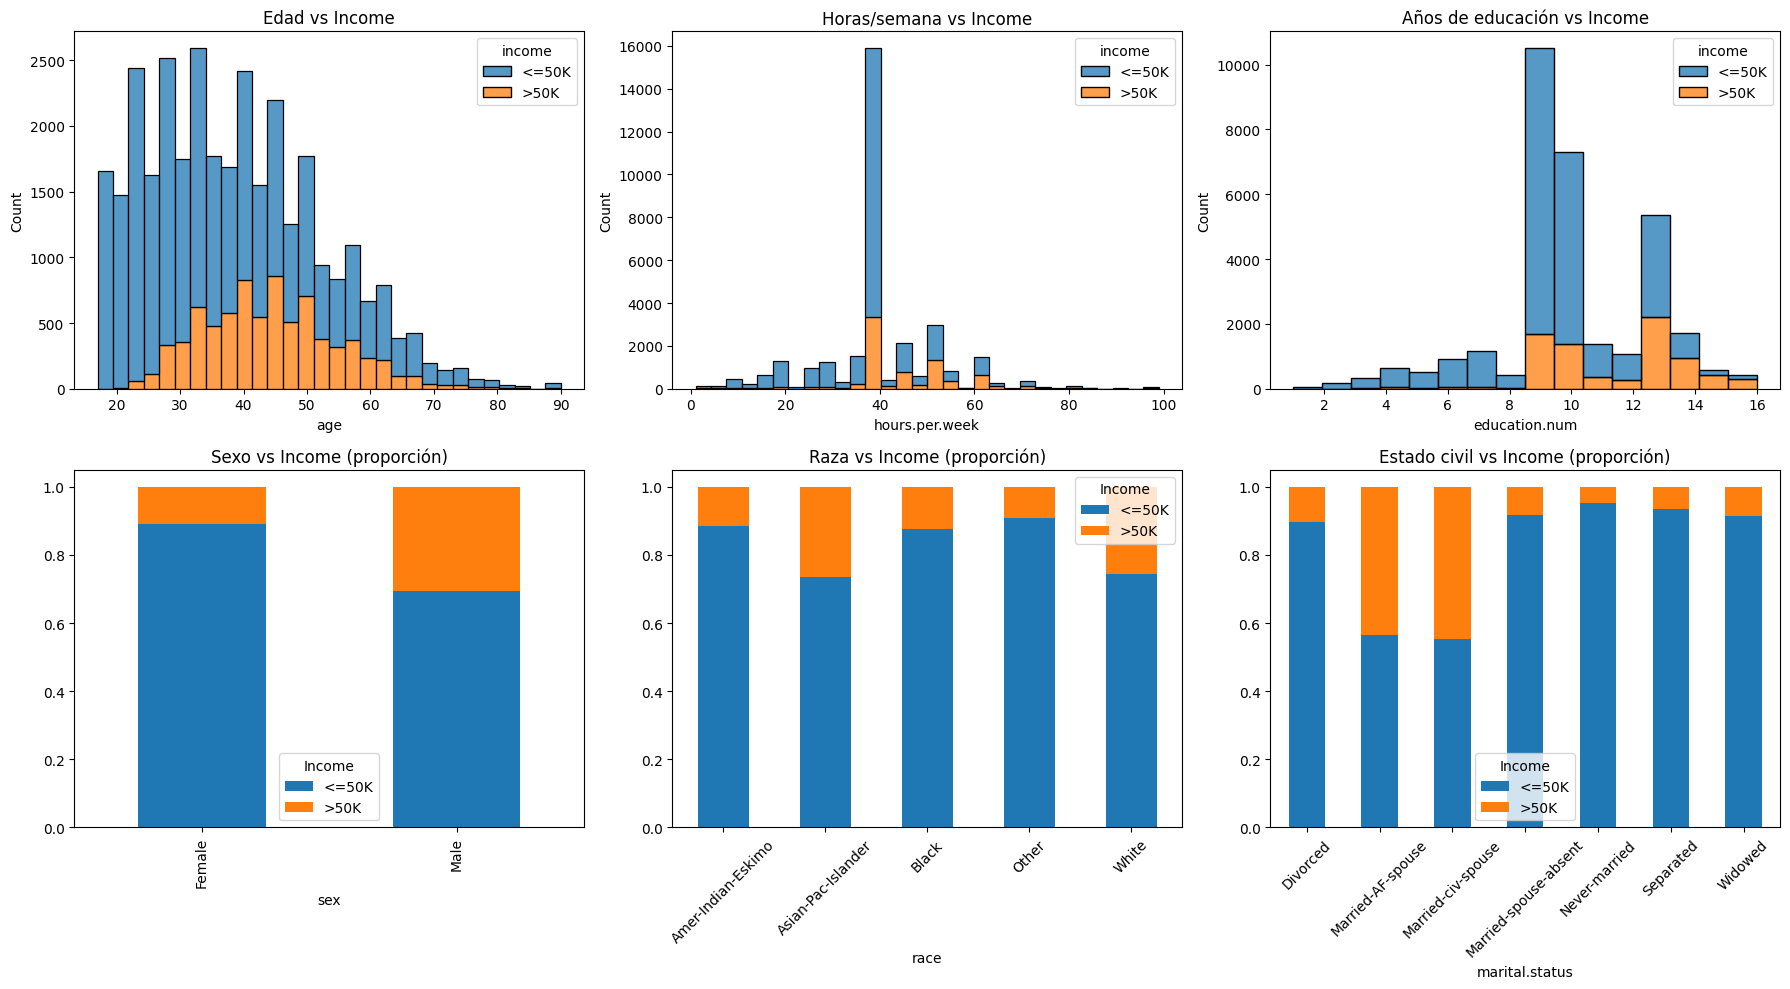

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Edad vs income
sns.histplot(data=df, x='age', hue='income', multiple='stack', bins=30, ax=axes[0,0])
axes[0,0].set_title('Edad vs Income')

# Horas trabajadas vs income
sns.histplot(data=df, x='hours.per.week', hue='income', multiple='stack', bins=30, ax=axes[0,1])
axes[0,1].set_title('Horas/semana vs Income')

# Educación (años) vs income
sns.histplot(data=df, x='education.num', hue='income', multiple='stack', bins=16, ax=axes[0,2])
axes[0,2].set_title('Años de educación vs Income')

# Sexo vs income (proporciones)
sex_income = pd.crosstab(df['sex'], df['income'], normalize='index')
sex_income.plot(kind='bar', stacked=True, ax=axes[1,0])
axes[1,0].set_title('Sexo vs Income (proporción)')
axes[1,0].legend(title='Income')

# Raza vs income (proporciones)
race_income = pd.crosstab(df['race'], df['income'], normalize='index')
race_income.plot(kind='bar', stacked=True, ax=axes[1,1])
axes[1,1].set_title('Raza vs Income (proporción)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend(title='Income')

# Estado civil vs income (proporciones)
marital_income = pd.crosstab(df['marital.status'], df['income'], normalize='index')
marital_income.plot(kind='bar', stacked=True, ax=axes[1,2])
axes[1,2].set_title('Estado civil vs Income (proporción)')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].legend(title='Income')

plt.tight_layout()
plt.show()

Edad: el grupo >50K se concentra entre 35-55 años; los más jóvenes (<30) casi no superan el umbral — tiene sentido, refleja acumulación de experiencia/carrera.

Horas trabajadas: la mayoría trabaja 40h/semana; la proporción de >50K aumenta claramente en el rango de 45-65h.

Años de educación: relación muy clara — a partir de ~13 años de educación (bachelor's) la proporción de >50K sube fuerte. Esta va a ser una variable central para las recomendaciones.

Sexo: brecha notable — ~30% de hombres superan 50K vs ~11% de mujeres.

Raza: White y Asian-Pac-Islander tienen mayor proporción de >50K que Black y Amer-Indian-Eskimo.

Estado civil: la brecha más marcada de todas — personas casadas (Married-civ-spouse/Married-AF-spouse) llegan a ~44% de >50K, contra ~5-10% en el resto.

In [8]:
# Reemplazamos "?" por NaN
df_clean = df.replace('?', np.nan)

print("Nulos por columna:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Vemos si los nulos coinciden entre workclass y occupation
print("\nFilas con ambos nulos (workclass y occupation):", 
      df_clean[df_clean['workclass'].isnull() & df_clean['occupation'].isnull()].shape[0])

# Imputamos con la moda, ya que son porcentajes bajos (<6%) y perder esas filas 
# no aporta, pero tampoco queremos perder ~5% de datos innecesariamente
for col in ['workclass', 'occupation', 'native.country']:
    moda = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(moda)

print("\nNulos después de imputar:", df_clean.isnull().sum().sum())

Nulos por columna:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Filas con ambos nulos (workclass y occupation): 1836

Nulos después de imputar: 0


In [9]:
# 'education' y 'education.num' son redundantes (education.num es la versión ordinal de education)
# Nos quedamos con education.num y eliminamos education
# 'fnlwgt' es un peso muestral del censo (no es una característica de la persona), lo eliminamos

df_model = df_clean.drop(columns=['education', 'fnlwgt'])

# Variable objetivo a binaria
df_model['income'] = df_model['income'].map({'<=50K': 0, '>50K': 1})

# Identificamos categóricas para encoding
cat_cols = df_model.select_dtypes(include='str').columns.tolist()
print("Categóricas a codificar:", cat_cols)

# One-hot encoding para categóricas nominales
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print("\nShape antes:", df_model.shape)
print("Shape después de encoding:", df_encoded.shape)
df_encoded.head()

Categóricas a codificar: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

Shape antes: (32561, 13)
Shape después de encoding: (32561, 82)


,age,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native.country_Canada,native.country_China,native.country_Columbia,native.country_Cuba,native.country_Dominican-Republic,native.country_Ecuador,native.country_El-Salvador,native.country_England,native.country_France,native.country_Germany,native.country_Greece,native.country_Guatemala,native.country_Haiti,native.country_Holand-Netherlands,native.country_Honduras,native.country_Hong,native.country_Hungary,native.country_India,native.country_Iran,native.country_Ireland,native.country_Italy,native.country_Jamaica,native.country_Japan,native.country_Laos,native.country_Mexico,native.country_Nicaragua,native.country_Outlying-US(Guam-USVI-etc),native.country_Peru,native.country_Philippines,native.country_Poland,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,9,0,4356,40,0,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,82,9,0,4356,18,0,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,66,10,0,4356,40,0,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,54,4,0,3900,40,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,41,10,0,3900,40,0,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False

**Train/Test**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=['income'])
y = df_encoded['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nProporción de clases en train:")
print(y_train.value_counts(normalize=True))
print("\nProporción de clases en test:")
print(y_test.value_counts(normalize=True))

# Escalado solo de las numéricas continuas
num_cols = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled[num_cols].describe()

Train shape: (26048, 81)
Test shape: (6513, 81)

Proporción de clases en train:
income
0    0.759175
1    0.240825
Name: proportion, dtype: float64

Proporción de clases en test:
income
0    0.759251
1    0.240749
Name: proportion, dtype: float64


,age,education.num,capital.gain,capital.loss,hours.per.week
count,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04
mean,4.173566e-17,2.858756e-16,1.200241e-17,2.509595e-17,-2.598249e-16
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-1.579794e+00,-3.523151e+00,-1.466132e-01,-2.178977e-01,-3.198368e+00
25%,-7.726573e-01,-4.192259e-01,-1.466132e-01,-2.178977e-01,-3.411963e-02
50%,-1.122726e-01,-3.123527e-02,-1.466132e-01,-2.178977e-01,-3.411963e-02
75%,6.214882e-01,7.447460e-01,-1.466132e-01,-2.178977e-01,3.715532e-01
max,3.776660e+00,2.296709e+00,1.334236e+01,1.049801e+01,4.752820e+00


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_proba))

print("\n=== Matriz de confusión ===")
print(confusion_matrix(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4945
           1       0.74      0.60      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513

AUC: 0.9022687702482409

=== Matriz de confusión ===
[[4606  339]
 [ 620  948]]


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Classification Report (Random Forest) ===")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))
print("\n=== Matriz de confusión ===")
print(confusion_matrix(y_test, y_pred_rf))

=== Classification Report (Random Forest) ===
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4945
           1       0.72      0.61      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.84      0.85      0.84      6513

AUC: 0.8905345922494378

=== Matriz de confusión ===
[[4566  379]
 [ 614  954]]


|Métrica|	Regresión Logística|	Random Forest|
|-------|-------|-------|
|AUC|	0.902|	0.890|
|Recall (clase >50K)|	0.60|	0.61|
|Precision (clase >50K)|	0.74|	0.72|
|F1 (clase >50K)|	0.66|	0.66|

Random Forest gana por poco en recall, pero la Regresión Logística tiene mejor AUC y precisión. No hay una diferencia que justifique complejidad adicional (tuning, más árboles, etc.) solo para ganar 1 punto porcentual.

=== Top 15 variables que MÁS aumentan la probabilidad de >50K ===
                             variable  coeficiente
2                        capital.gain     2.291020
13  marital.status_Married-civ-spouse     1.756746
12   marital.status_Married-AF-spouse     1.685350
35                  relationship_Wife     1.161362
61               native.country_Italy     0.779708
1                       education.num     0.769765
40                           sex_Male     0.743980
20         occupation_Exec-managerial     0.717209
29            occupation_Tech-support     0.631740
69         native.country_Philippines     0.523674
50             native.country_Germany     0.515154
27         occupation_Protective-serv     0.508996
49              native.country_France     0.498429
60             native.country_Ireland     0.452190
44                native.country_Cuba     0.439005

=== Top 15 variables que MÁS disminuyen la probabilidad de >50K ===
                             variable  coeficient

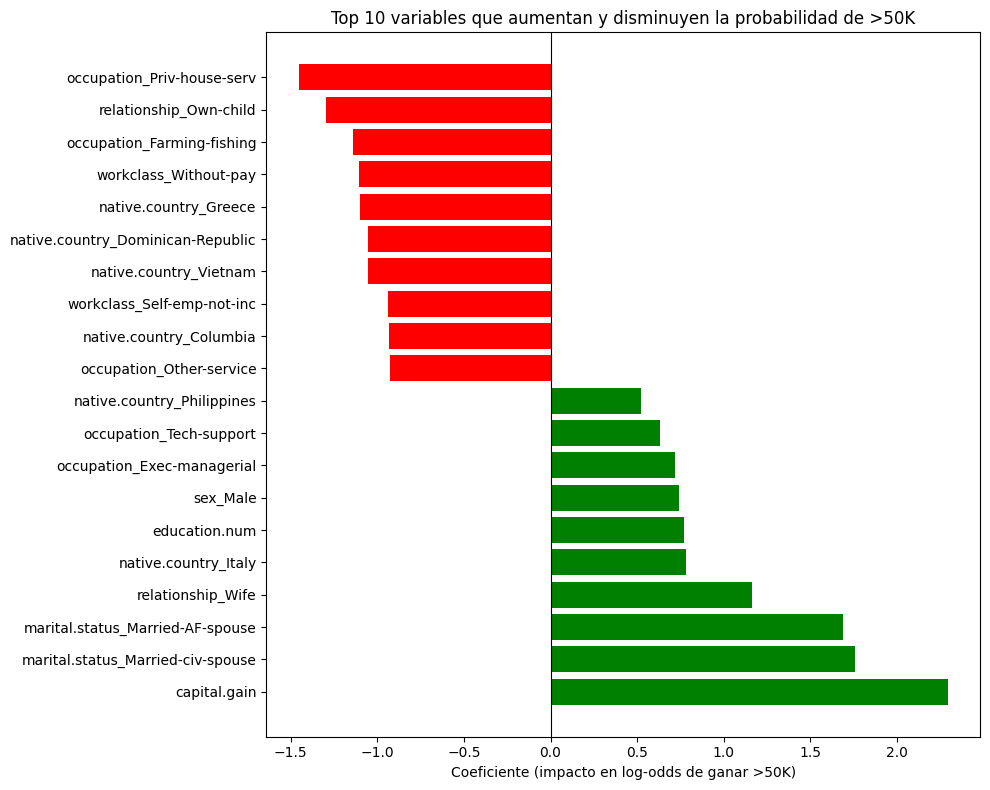

In [13]:
coef_df = pd.DataFrame({
    'variable': X_train_scaled.columns,
    'coeficiente': log_reg.coef_[0]
}).sort_values('coeficiente', ascending=False)

print("=== Top 15 variables que MÁS aumentan la probabilidad de >50K ===")
print(coef_df.head(15))

print("\n=== Top 15 variables que MÁS disminuyen la probabilidad de >50K ===")
print(coef_df.tail(15))

# Visualización
top_20 = pd.concat([coef_df.head(10), coef_df.tail(10)])
plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in top_20['coeficiente']]
plt.barh(top_20['variable'], top_20['coeficiente'], color=colors)
plt.xlabel('Coeficiente (impacto en log-odds de ganar >50K)')
plt.title('Top 10 variables que aumentan y disminuyen la probabilidad de >50K')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

- ¿Qué se quiere recomendar? Cambios en variables accionables (education.num, occupation, workclass, hours.per.week) que acerquen el perfil del usuario al de personas similares que sí superan 50K.
- ¿Cuál es el "usuario"? Cualquier persona (real del dataset o simulada) representada como un vector de características.
- ¿Qué variables definen el perfil? Todas las columnas del dataset — pero separadas en dos roles: variables de contexto/similitud (fijas, incluidas age, sex, race, native.country, marital.status, relationship — sirven para encontrar personas parecidas) y variables de recomendación (accionables — sirven para generar la sugerencia).

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# Variables accionables sobre las que vamos a generar recomendaciones
ACCIONABLES_NUM = ['education.num', 'hours.per.week']
ACCIONABLES_OCC = [c for c in X.columns if c.startswith('occupation_')]
ACCIONABLES_WORK = [c for c in X.columns if c.startswith('workclass_')]

# Escalamos TODO el dataset (no solo train) usando el scaler ya ajustado en train,
# para poder buscar similitud contra cualquier perfil exitoso del dataset completo
X_full_scaled = X.copy()
X_full_scaled[num_cols] = scaler.transform(X[num_cols])

# Banco de perfiles "exitosos" (income > 50K)
exitosos_mask = (y == 1)
banco_exitosos = X_full_scaled[exitosos_mask]

print("Perfiles exitosos en el banco:", banco_exitosos.shape[0])

def encontrar_similares(perfil_usuario_vector, k=15):
    """
    Recibe un vector de perfil (alineado con las columnas de X_full_scaled)
    y retorna los índices e índice de similitud de los k perfiles exitosos más parecidos.
    """
    similitudes = cosine_similarity([perfil_usuario_vector], banco_exitosos)[0]
    top_k_idx = np.argsort(similitudes)[-k:][::-1]
    return banco_exitosos.iloc[top_k_idx].index, similitudes[top_k_idx]

# --- Prueba rápida ---
# Tomamos un perfil real del test set que gana <=50K y buscamos sus vecinos exitosos
idx_prueba = X_test_scaled[y_test == 0].index[0]
perfil_prueba = X_test_scaled.loc[idx_prueba]

indices_similares, sims = encontrar_similares(perfil_prueba, k=15)

print("\nSimilitud promedio de los vecinos encontrados:", sims.mean())

print("\n--- Perfil original (variables accionables) ---")
print("education.num:", df_encoded.loc[idx_prueba, 'education.num'])
print("hours.per.week:", df_encoded.loc[idx_prueba, 'hours.per.week'])
print("occupation:", df_clean.loc[idx_prueba, 'occupation'])
print("workclass:", df_clean.loc[idx_prueba, 'workclass'])

print("\n--- Vecinos exitosos (mediana/moda de variables accionables) ---")
print("education.num mediana:", df_encoded.loc[indices_similares, 'education.num'].median())
print("hours.per.week mediana:", df_encoded.loc[indices_similares, 'hours.per.week'].median())
print("occupation más común:", df_clean.loc[indices_similares, 'occupation'].mode()[0])
print("workclass más común:", df_clean.loc[indices_similares, 'workclass'].mode()[0])

Perfiles exitosos en el banco: 7841

Similitud promedio de los vecinos encontrados: 0.8265611841451993

--- Perfil original (variables accionables) ---
education.num: 13
hours.per.week: 45
occupation: Tech-support
workclass: Self-emp-not-inc

--- Vecinos exitosos (mediana/moda de variables accionables) ---
education.num mediana: 13.0
hours.per.week mediana: 45.0
occupation más común: Prof-specialty
workclass más común: Self-emp-not-inc


Muy buen resultado y particularmente interesante porque el perfil de prueba ya tiene valores altos en education.num (13) y hours.per.week (45), casi idénticos a la mediana de sus vecinos exitosos. Esto nos dice algo importante: el sistema está funcionando bien, porque no está inventando diferencias donde no las hay.

La única diferencia real que detecta es en occupation: el usuario está en Tech-support, mientras que sus vecinos similares y exitosos tienden más hacia Prof-specialty. Es una recomendación sensata y con sentido de negocio (ocupaciones profesionales especializadas suelen pagar más que soporte técnico, aun con el mismo nivel educativo).

Esto también valida un punto importante para las conclusiones: el sistema no siempre va a tener una recomendación de "estudiar más" — a veces el diferenciador está en la ocupación o el régimen laboral, no en la educación. Eso hace el sistema más rico que una regla simple tipo "sube tu nivel educativo".

In [15]:
def generar_recomendaciones(idx_usuario, k=15, umbral_educacion=1.0, umbral_horas=5.0):
    """
    Genera recomendaciones textuales para un usuario del dataset (por índice)
    comparando sus variables accionables contra sus k vecinos exitosos más similares.
    """
    perfil_vector = X_full_scaled.loc[idx_usuario]
    indices_similares, sims = encontrar_similares(perfil_vector, k=k)

    recomendaciones = []

    # --- Educación ---
    edu_usuario = df_encoded.loc[idx_usuario, 'education.num']
    edu_vecinos = df_encoded.loc[indices_similares, 'education.num'].median()
    if edu_vecinos - edu_usuario >= umbral_educacion:
        recomendaciones.append(
            f"Aumentar el nivel educativo: perfiles similares exitosos tienen en mediana "
            f"{edu_vecinos:.0f} años de educación formal, frente a tus {edu_usuario} actuales."
        )

    # --- Horas trabajadas ---
    horas_usuario = df_encoded.loc[idx_usuario, 'hours.per.week']
    horas_vecinos = df_encoded.loc[indices_similares, 'hours.per.week'].median()
    if abs(horas_vecinos - horas_usuario) >= umbral_horas:
        direccion = "aumentar" if horas_vecinos > horas_usuario else "reducir"
        recomendaciones.append(
            f"Considerar {direccion} las horas trabajadas por semana: perfiles similares "
            f"exitosos trabajan en mediana {horas_vecinos:.0f}h, frente a tus {horas_usuario}h actuales."
        )

    # --- Ocupación ---
    occ_usuario = df_clean.loc[idx_usuario, 'occupation']
    occ_vecinos = df_clean.loc[indices_similares, 'occupation'].mode()[0]
    if occ_vecinos != occ_usuario:
        pct = (df_clean.loc[indices_similares, 'occupation'] == occ_vecinos).mean() * 100
        recomendaciones.append(
            f"Explorar una transición hacia el área de '{occ_vecinos}': es la ocupación más común "
            f"({pct:.0f}% de los casos) entre perfiles similares que superan los 50K, "
            f"frente a tu ocupación actual ('{occ_usuario}')."
        )

    # --- Tipo de empleo (workclass) ---
    work_usuario = df_clean.loc[idx_usuario, 'workclass']
    work_vecinos = df_clean.loc[indices_similares, 'workclass'].mode()[0]
    if work_vecinos != work_usuario:
        pct = (df_clean.loc[indices_similares, 'workclass'] == work_vecinos).mean() * 100
        recomendaciones.append(
            f"Evaluar un cambio de régimen laboral hacia '{work_vecinos}': predomina "
            f"({pct:.0f}% de los casos) en perfiles similares exitosos, frente a tu régimen actual ('{work_usuario}')."
        )

    if not recomendaciones:
        recomendaciones.append(
            "Tu perfil ya es muy similar, en variables accionables, a personas que superan los 50K anuales. "
            "No se identifican cambios de trayectoria claros; otros factores (ej. capital.gain) pueden explicar la diferencia."
        )

    return recomendaciones, sims.mean()

# --- Prueba con el mismo caso anterior ---
recs, similitud_promedio = generar_recomendaciones(idx_prueba)
print(f"Similitud promedio con vecinos exitosos: {similitud_promedio:.3f}\n")
for i, r in enumerate(recs, 1):
    print(f"{i}. {r}")

Similitud promedio con vecinos exitosos: 0.827

1. Explorar una transición hacia el área de 'Prof-specialty': es la ocupación más común (47% de los casos) entre perfiles similares que superan los 50K, frente a tu ocupación actual ('Tech-support').


**Función para construir el vector de un usuario simulado**

In [16]:
def construir_vector_usuario(perfil_dict):
    """
    Recibe un diccionario con las variables originales del censo (sin codificar)
    y devuelve un vector alineado con las columnas de X (mismo orden, mismo one-hot, escalado).
    Cualquier variable categórica no especificada, o valor no visto en el training, se ignora (queda en 0).
    """
    # Partimos de un vector de ceros con las columnas de X
    vector = pd.Series(0, index=X.columns, dtype=float)

    # Variables numéricas directas
    for col in ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']:
        if col in perfil_dict:
            vector[col] = perfil_dict[col]

    # Variables categóricas -> activar la dummy correspondiente
    cat_map = {
        'workclass': 'workclass_',
        'marital.status': 'marital.status_',
        'occupation': 'occupation_',
        'relationship': 'relationship_',
        'race': 'race_',
        'sex': 'sex_',
        'native.country': 'native.country_'
    }

    for col, prefix in cat_map.items():
        if col in perfil_dict:
            dummy_col = f"{prefix}{perfil_dict[col]}"
            if dummy_col in vector.index:
                vector[dummy_col] = 1
            # Si no existe (ej. era la categoría "drop_first" de referencia, o no vista), se queda en 0 correctamente

    # Escalar las numéricas usando el mismo scaler ya ajustado
    vector_df = pd.DataFrame([vector])
    vector_df[num_cols] = scaler.transform(vector_df[num_cols])

    return vector_df.iloc[0]


def recomendar_para_perfil_nuevo(perfil_dict, k=15, umbral_educacion=1.0, umbral_horas=5.0):
    """
    Igual que generar_recomendaciones, pero para un perfil simulado (no perteneciente al dataset).
    """
    vector_usuario = construir_vector_usuario(perfil_dict)
    indices_similares, sims = encontrar_similares(vector_usuario, k=k)

    recomendaciones = []

    edu_usuario = perfil_dict.get('education.num', 0)
    edu_vecinos = df_encoded.loc[indices_similares, 'education.num'].median()
    if edu_vecinos - edu_usuario >= umbral_educacion:
        recomendaciones.append(
            f"Aumentar el nivel educativo: perfiles similares exitosos tienen en mediana "
            f"{edu_vecinos:.0f} años de educación formal, frente a tus {edu_usuario} actuales."
        )

    horas_usuario = perfil_dict.get('hours.per.week', 0)
    horas_vecinos = df_encoded.loc[indices_similares, 'hours.per.week'].median()
    if abs(horas_vecinos - horas_usuario) >= umbral_horas:
        direccion = "aumentar" if horas_vecinos > horas_usuario else "reducir"
        recomendaciones.append(
            f"Considerar {direccion} las horas trabajadas por semana: perfiles similares "
            f"exitosos trabajan en mediana {horas_vecinos:.0f}h, frente a tus {horas_usuario}h actuales."
        )

    occ_usuario = perfil_dict.get('occupation', 'No especificada')
    occ_vecinos = df_clean.loc[indices_similares, 'occupation'].mode()[0]
    if occ_vecinos != occ_usuario:
        pct = (df_clean.loc[indices_similares, 'occupation'] == occ_vecinos).mean() * 100
        recomendaciones.append(
            f"Explorar una transición hacia el área de '{occ_vecinos}': es la ocupación más común "
            f"({pct:.0f}% de los casos) entre perfiles similares que superan los 50K, "
            f"frente a tu ocupación actual ('{occ_usuario}')."
        )

    work_usuario = perfil_dict.get('workclass', 'No especificado')
    work_vecinos = df_clean.loc[indices_similares, 'workclass'].mode()[0]
    if work_vecinos != work_usuario:
        pct = (df_clean.loc[indices_similares, 'workclass'] == work_vecinos).mean() * 100
        recomendaciones.append(
            f"Evaluar un cambio de régimen laboral hacia '{work_vecinos}': predomina "
            f"({pct:.0f}% de los casos) en perfiles similares exitosos, frente a tu régimen actual ('{work_usuario}')."
        )

    if not recomendaciones:
        recomendaciones.append(
            "Tu perfil ya es muy similar, en variables accionables, a personas que superan los 50K anuales."
        )

    return recomendaciones, sims.mean()


# --- Ejemplo del enunciado: 25 años, secundario completo, trabaja medio tiempo ---
perfil_usuario = {
    'age': 25,
    'workclass': 'Private',
    'education.num': 9,          # secundario completo (~HS-grad)
    'marital.status': 'Never-married',
    'occupation': 'Other-service',
    'relationship': 'Not-in-family',
    'race': 'White',
    'sex': 'Male',
    'capital.gain': 0,
    'capital.loss': 0,
    'hours.per.week': 20,        # medio tiempo
    'native.country': 'United-States'
}

recs, similitud_promedio = recomendar_para_perfil_nuevo(perfil_usuario)
print(f"Similitud promedio con vecinos exitosos: {similitud_promedio:.3f}\n")
for i, r in enumerate(recs, 1):
    print(f"{i}. {r}")

Similitud promedio con vecinos exitosos: 0.760

1. Aumentar el nivel educativo: perfiles similares exitosos tienen en mediana 10 años de educación formal, frente a tus 9 actuales.
2. Considerar aumentar las horas trabajadas por semana: perfiles similares exitosos trabajan en mediana 35h, frente a tus 20h actuales.


In [17]:
perfiles_simulados = {
    "Joven medio tiempo (caso base)": perfil_usuario,  # Ya simulado

    "Adulto con estudios pero ocupación operativa": {
        'age': 35,
        'workclass': 'Private',
        'education.num': 13,        # Universidad
        'marital.status': 'Never-married',
        'occupation': 'Handlers-cleaners',
        'relationship': 'Not-in-family',
        'race': 'White',
        'sex': 'Female',
        'capital.gain': 0,
        'capital.loss': 0,
        'hours.per.week': 40,
        'native.country': 'United-States'
    },

    "Adulto casado, bajo nivel educativo": {
        'age': 45,
        'workclass': 'Private',
        'education.num': 6,          # Primaria
        'marital.status': 'Married-civ-spouse',
        'occupation': 'Farming-fishing',
        'relationship': 'Husband',
        'race': 'White',
        'sex': 'Male',
        'capital.gain': 0,
        'capital.loss': 0,
        'hours.per.week': 50,
        'native.country': 'United-States'
    },

    "Perfil ya fuerte (cerca del umbral)": {
        'age': 40,
        'workclass': 'Private',
        'education.num': 13,
        'marital.status': 'Married-civ-spouse',
        'occupation': 'Prof-specialty',
        'relationship': 'Husband',
        'race': 'White',
        'sex': 'Male',
        'capital.gain': 0,
        'capital.loss': 0,
        'hours.per.week': 45,
        'native.country': 'United-States'
    }
}

for nombre, perfil in perfiles_simulados.items():
    recs, sim_prom = recomendar_para_perfil_nuevo(perfil)
    print(f"{'='*70}")
    print(f"PERFIL: {nombre}")
    print(f"Similitud promedio con vecinos exitosos: {sim_prom:.3f}")
    print("-"*70)
    for i, r in enumerate(recs, 1):
        print(f"{i}. {r}")
    print()

PERFIL: Joven medio tiempo (caso base)
Similitud promedio con vecinos exitosos: 0.760
----------------------------------------------------------------------
1. Aumentar el nivel educativo: perfiles similares exitosos tienen en mediana 10 años de educación formal, frente a tus 9 actuales.
2. Considerar aumentar las horas trabajadas por semana: perfiles similares exitosos trabajan en mediana 35h, frente a tus 20h actuales.

PERFIL: Adulto con estudios pero ocupación operativa
Similitud promedio con vecinos exitosos: 0.855
----------------------------------------------------------------------
1. Aumentar el nivel educativo: perfiles similares exitosos tienen en mediana 14 años de educación formal, frente a tus 13 actuales.
2. Explorar una transición hacia el área de 'Prof-specialty': es la ocupación más común (53% de los casos) entre perfiles similares que superan los 50K, frente a tu ocupación actual ('Handlers-cleaners').

PERFIL: Adulto casado, bajo nivel educativo
Similitud promedio c

- Joven medio tiempo: recomienda más educación y más horas — coherente y esperado.
- Adulto con estudios pero ocupación operativa: aquí el sistema es más fino — no repite "estudia más" de forma genérica, sino que detecta que el problema real es la ocupación (Handlers-cleaners vs Prof-specialty), aunque también sugiere un empujón educativo adicional. Buen ejemplo de recomendación específica y no trivial.
- Adulto casado, bajo nivel educativo: el sistema dice que "ya es muy similar" a perfiles exitosos — esto merece atención crítica. Con solo 6 años de educación y ocupación Farming-fishing (que vimos en la Celda 9 con uno de los coeficientes más negativos), es contraintuitivo que no haya recomendaciones.
- Perfil ya fuerte: similitud casi perfecta (0.997) — el sistema reconoce correctamente que este perfil ya está en la zona "exitosa", sin necesidad de cambios. Esto valida bien el comportamiento esperado.

¿Por qué pasa lo del caso 3? marital.status_Married-civ-spouse tiene un coeficiente altísimo (1.76, el segundo más fuerte del modelo) y domina el cálculo de similitud de coseno al ser una variable binaria de alto peso relativo entre tantas dummies. El sistema está encontrando "hombres casados que trabajan muchas horas" como sus vecinos más similares, y entre esos, probablemente también hay agricultores con bajo nivel educativo que sí superan 50K (ej. dueños de tierra, no jornaleros). Es decir, el sistema está siendo "engañado" por el estado civil, que es una variable de contexto pero no debería ser la que domine la búsqueda de similitud.

In [18]:
perfil_caso3 = perfiles_simulados["Adulto casado, bajo nivel educativo"]
vector_caso3 = construir_vector_usuario(perfil_caso3)
indices_similares_c3, sims_c3 = encontrar_similares(vector_caso3, k=15)

print("=== Composición del vecindario (Adulto casado, bajo nivel educativo) ===\n")

vecinos_detalle = df_clean.loc[indices_similares_c3, 
    ['age', 'education.num', 'marital.status', 'occupation', 'workclass', 'hours.per.week', 'sex']].copy()
vecinos_detalle['similitud'] = sims_c3

print(vecinos_detalle.sort_values('similitud', ascending=False).to_string())

print("\n--- Resumen ---")
print("Estado civil de los vecinos:")
print(vecinos_detalle['marital.status'].value_counts())
print("\nOcupación de los vecinos:")
print(vecinos_detalle['occupation'].value_counts())
print("\nMediana education.num de vecinos:", vecinos_detalle['education.num'].median())
print("Perfil original tenía education.num:", perfil_caso3['education.num'])

=== Composición del vecindario (Adulto casado, bajo nivel educativo) ===

       age  education.num      marital.status         occupation         workclass  hours.per.week   sex  similitud
13948   44              7  Married-civ-spouse       Adm-clerical           Private              40  Male   0.900311
15156   64              4  Married-civ-spouse    Farming-fishing           Private              40  Male   0.894072
30649   55              9  Married-civ-spouse    Farming-fishing           Private              53  Male   0.893023
12862   51              5  Married-civ-spouse       Craft-repair           Private              50  Male   0.891387
26616   50              9  Married-civ-spouse    Farming-fishing           Private              60  Male   0.886260
21226   47              6  Married-civ-spouse  Machine-op-inspct           Private              46  Male   0.885551
23241   55              9  Married-civ-spouse    Farming-fishing           Private              45  Male   0.88432

**Conclusión del 3er perfil**

El peso de marital.status_Married-civ-spouse en el modelo (segundo coeficiente más alto) hace que domine la similitud de coseno sobre variables con menor magnitud de coeficiente pero mayor relevancia práctica como recomendación. Es una limitación real del enfoque de "vector completo + coseno", no un fallo aislado.

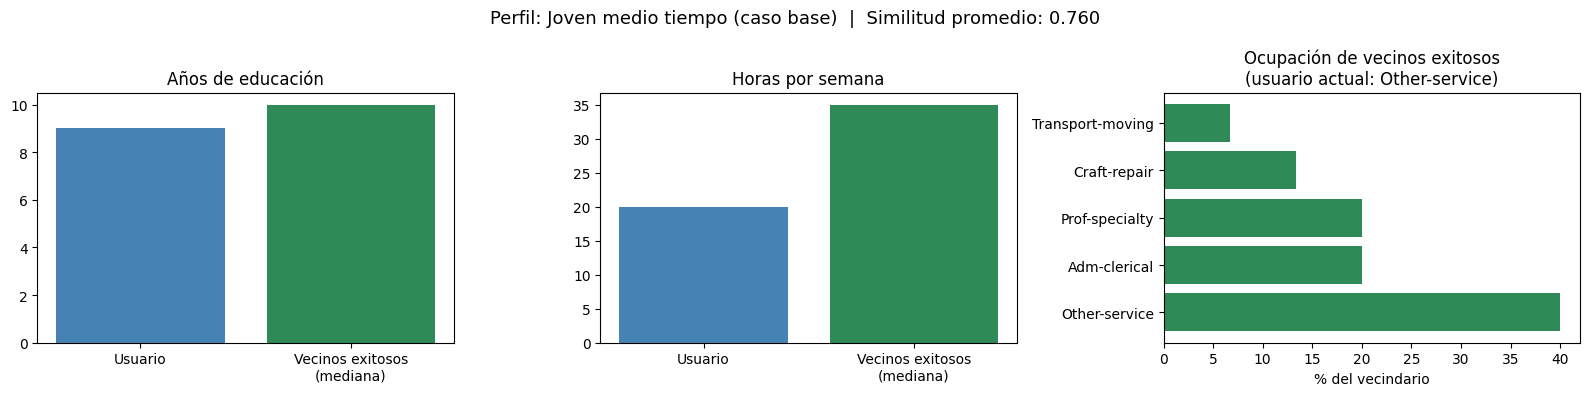

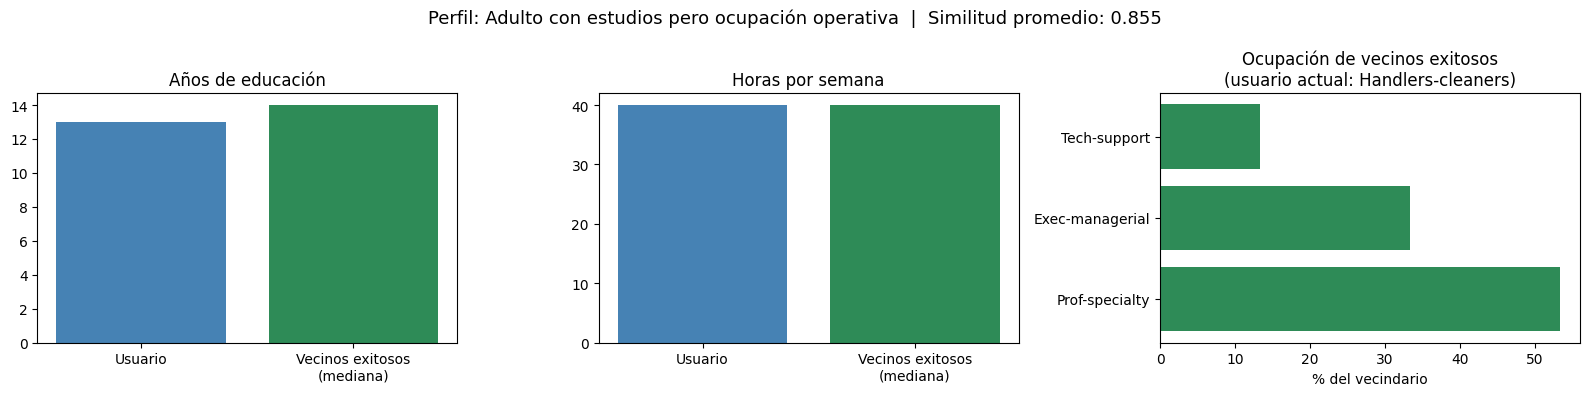

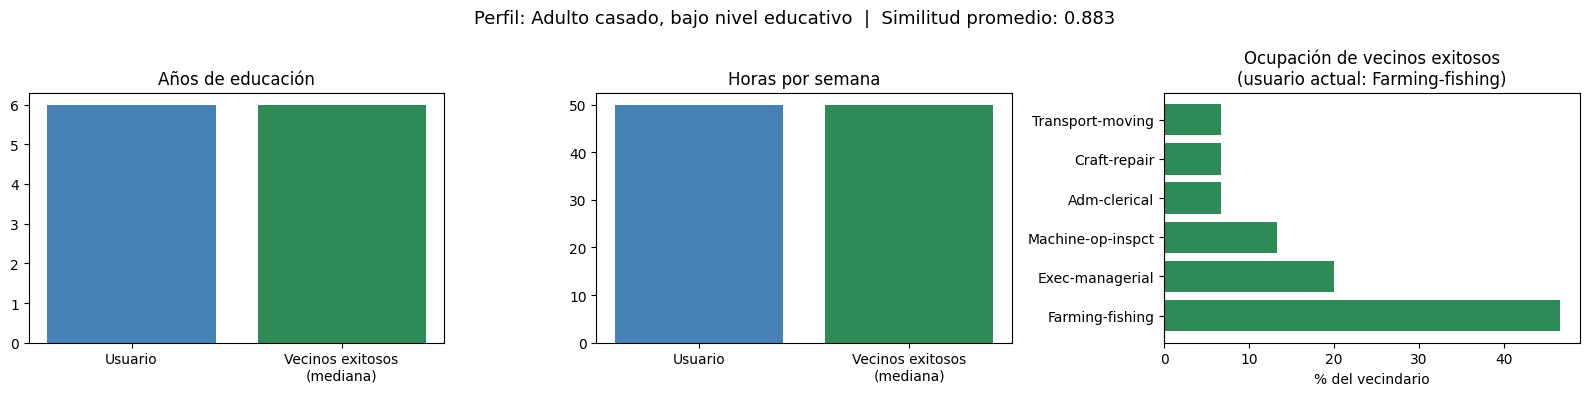

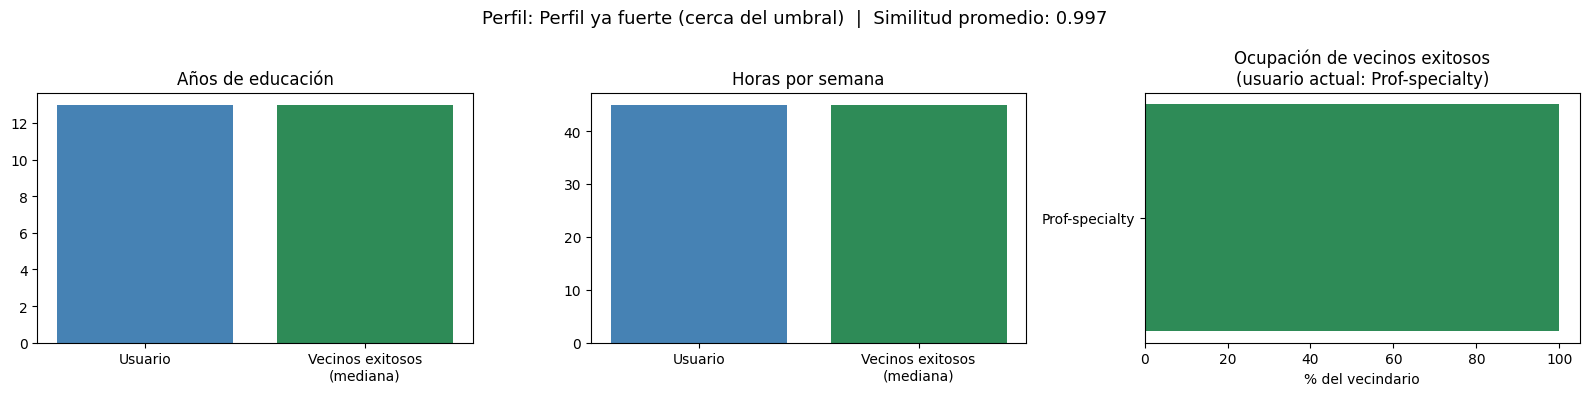

In [19]:
def graficar_comparacion(nombre_perfil, perfil_dict, k=15):
    vector_usuario = construir_vector_usuario(perfil_dict)
    indices_similares, sims = encontrar_similares(vector_usuario, k=k)

    edu_usuario = perfil_dict.get('education.num', 0)
    edu_vecinos = df_encoded.loc[indices_similares, 'education.num'].median()

    horas_usuario = perfil_dict.get('hours.per.week', 0)
    horas_vecinos = df_encoded.loc[indices_similares, 'hours.per.week'].median()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Perfil: {nombre_perfil}  |  Similitud promedio: {sims.mean():.3f}", fontsize=13)

    # Educación
    axes[0].bar(['Usuario', 'Vecinos exitosos\n(mediana)'], [edu_usuario, edu_vecinos], color=['steelblue', 'seagreen'])
    axes[0].set_title('Años de educación')

    # Horas
    axes[1].bar(['Usuario', 'Vecinos exitosos\n(mediana)'], [horas_usuario, horas_vecinos], color=['steelblue', 'seagreen'])
    axes[1].set_title('Horas por semana')

    # Ocupación (distribución de vecinos)
    occ_dist = df_clean.loc[indices_similares, 'occupation'].value_counts(normalize=True) * 100
    axes[2].barh(occ_dist.index, occ_dist.values, color='seagreen')
    occ_usuario = perfil_dict.get('occupation', 'N/A')
    axes[2].set_title(f"Ocupación de vecinos exitosos\n(usuario actual: {occ_usuario})")
    axes[2].set_xlabel('% del vecindario')

    plt.tight_layout()
    plt.show()

# Graficamos los 4 perfiles simulados
for nombre, perfil in perfiles_simulados.items():
    graficar_comparacion(nombre, perfil)